# Model Validation and Calibration

Checking whether the selected model produces well-calibrated probabilities and how performance changes across different thresholds. In credit risk, ranking quality matters more than raw accuracy.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
metrics = pd.read_csv(ROOT / "data" / "processed" / "model_metrics.csv")
calibration = pd.read_csv(ROOT / "data" / "processed" / "calibration_table.csv")
risk_bands = pd.read_csv(ROOT / "data" / "processed" / "risk_band_summary.csv")
sensitivity = pd.read_csv(ROOT / "data" / "processed" / "threshold_sensitivity.csv")
metrics


,model,roc_auc,precision,recall,f1_score,brier_score,true_positive,false_positive,true_negative,false_negative,threshold
0,logistic_regression,0.812246,0.440559,0.488372,0.463235,0.093072,63,80,751,66,0.3
1,random_forest,0.802461,0.495327,0.410853,0.449153,0.096451,53,54,777,76,0.3
2,gradient_boosting,0.795772,0.527473,0.372093,0.436364,0.097965,48,43,788,81,0.3
3,decision_tree,0.778375,0.388889,0.434109,0.410256,0.101381,56,88,743,73,0.3


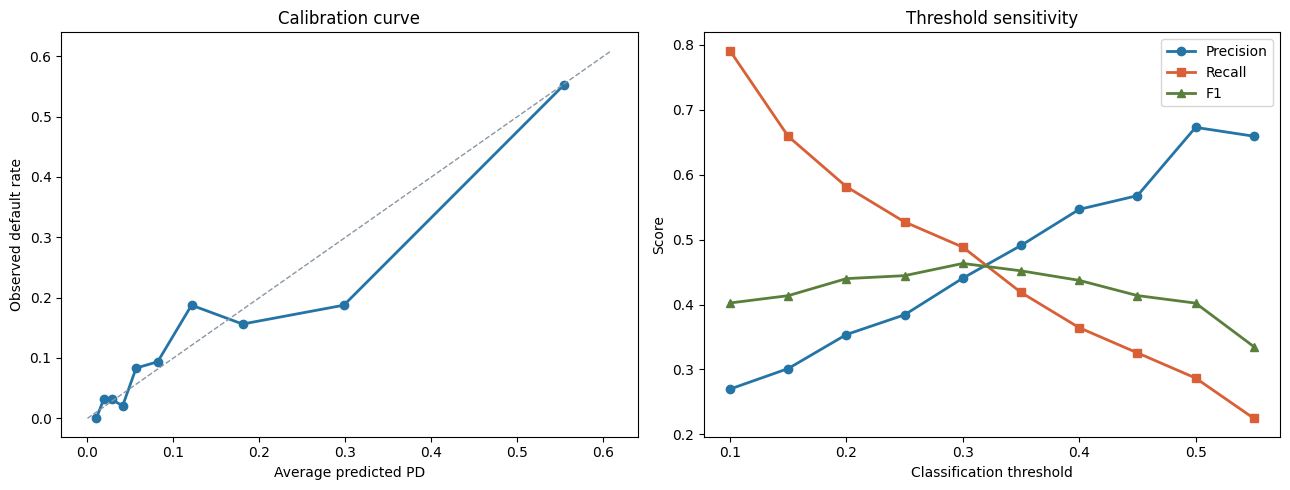

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    calibration["average_predicted_pd"],
    calibration["observed_default_rate"],
    "o-", color="#2474a6", linewidth=2, markersize=6,
)
lim = max(calibration["average_predicted_pd"].max(), calibration["observed_default_rate"].max()) * 1.1
axes[0].plot([0, lim], [0, lim], "--", color="#8996a3", linewidth=1)
axes[0].set_title("Calibration curve")
axes[0].set_xlabel("Average predicted PD")
axes[0].set_ylabel("Observed default rate")

axes[1].plot(sensitivity["threshold"], sensitivity["precision"], "o-", label="Precision", color="#2474a6", linewidth=2)
axes[1].plot(sensitivity["threshold"], sensitivity["recall"], "s-", label="Recall", color="#d95f36", linewidth=2)
axes[1].plot(sensitivity["threshold"], sensitivity["f1_score"], "^-", label="F1", color="#5a7f3b", linewidth=2)
axes[1].set_title("Threshold sensitivity")
axes[1].set_xlabel("Classification threshold")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.show()


In [3]:
calibration


,calibration_bin,customers,average_predicted_pd,observed_default_rate
0,1,96,0.010304,0.000000
1,2,96,0.018790,0.031250
2,3,96,0.028046,0.031250
3,4,96,0.040920,0.020833
4,5,96,0.056587,0.083333
5,6,96,0.081668,0.093750
6,7,96,0.121003,0.187500
7,8,96,0.180344,0.156250
8,9,96,0.298127,0.187500
9,10,96,0.553770,0.552083


In [4]:
risk_bands


,risk_band,customers,average_predicted_pd,observed_default_rate,average_limit_balance
0,A,640,0.014592,0.014063,113015.6250
1,B,640,0.034902,0.032813,91429.6875
2,C,640,0.068176,0.073438,83848.4375
3,D,640,0.143499,0.140625,80289.0625
4,E,640,0.408250,0.396875,74242.1875


In [5]:
sensitivity


,threshold,precision,recall,f1_score,flagged_share
0,0.10,0.269841,0.790698,0.402367,0.393750
1,0.15,0.301418,0.658915,0.413625,0.293750
2,0.20,0.353774,0.581395,0.439883,0.220833
3,0.25,0.384181,0.527132,0.444444,0.184375
4,0.30,0.440559,0.488372,0.463235,0.148958
5,0.35,0.490909,0.418605,0.451883,0.114583
6,0.40,0.546512,0.364341,0.437209,0.089583
7,0.45,0.567568,0.325581,0.413793,0.077083
8,0.50,0.672727,0.286822,0.402174,0.057292
9,0.55,0.659091,0.224806,0.335260,0.045833


## Threshold analysis

F1 peaks around 0.30, so the initial choice turns out to be reasonable. But F1 treats precision and recall equally, and in credit risk they usually aren't equally important. Missing a default (false negative) typically costs more than an unnecessary review (false positive), so it's worth looking at what a lower threshold buys us.

In [6]:
print("Threshold comparison: precision vs recall tradeoff\n")
for _, row in sensitivity.iterrows():
    marker = " ◀ F1 peak" if row["f1_score"] == sensitivity["f1_score"].max() else ""
    print(f"  {row['threshold']:.2f}  |  P {row['precision']:.3f}  R {row['recall']:.3f}  F1 {row['f1_score']:.3f}  |  flagged {row['flagged_share']:.1%}{marker}")

print()
print("At 0.30: ~49% of actual defaults caught, ~15% of portfolio flagged for review")
print("At 0.20: ~58% of actual defaults caught, ~22% of portfolio flagged")
print("At 0.15: ~66% of actual defaults caught, ~29% of portfolio flagged")

Threshold comparison: precision vs recall tradeoff

  0.10  |  P 0.270  R 0.791  F1 0.402  |  flagged 39.4%
  0.15  |  P 0.301  R 0.659  F1 0.414  |  flagged 29.4%
  0.20  |  P 0.354  R 0.581  F1 0.440  |  flagged 22.1%
  0.25  |  P 0.384  R 0.527  F1 0.444  |  flagged 18.4%
  0.30  |  P 0.441  R 0.488  F1 0.463  |  flagged 14.9% ◀ F1 peak
  0.35  |  P 0.491  R 0.419  F1 0.452  |  flagged 11.5%
  0.40  |  P 0.547  R 0.364  F1 0.437  |  flagged 9.0%
  0.45  |  P 0.568  R 0.326  F1 0.414  |  flagged 7.7%
  0.50  |  P 0.673  R 0.287  F1 0.402  |  flagged 5.7%
  0.55  |  P 0.659  R 0.225  F1 0.335  |  flagged 4.6%

At 0.30: ~49% of actual defaults caught, ~15% of portfolio flagged for review
At 0.20: ~58% of actual defaults caught, ~22% of portfolio flagged
At 0.15: ~66% of actual defaults caught, ~29% of portfolio flagged


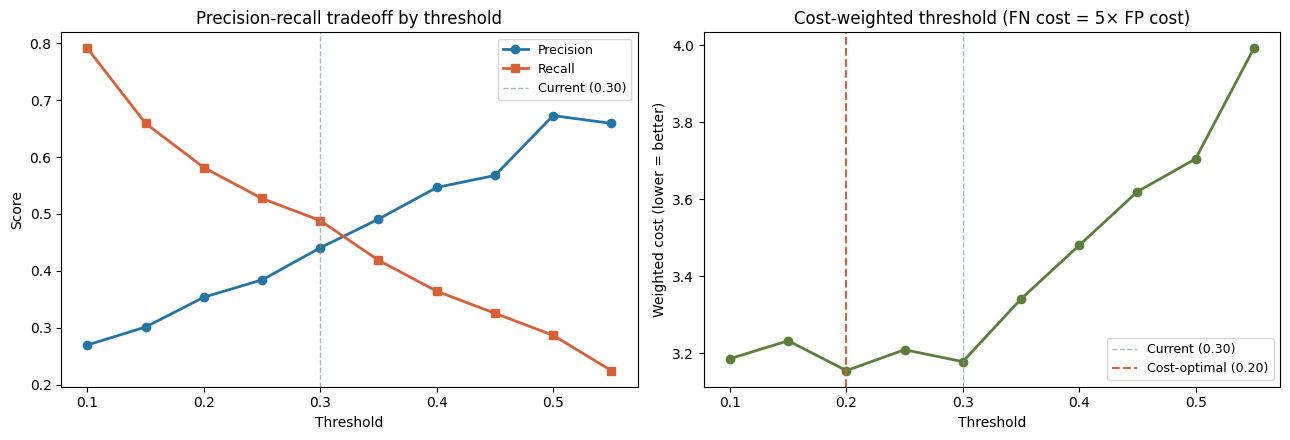


If false negatives cost 5× more than false positives, optimal threshold = 0.20


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# left: precision-recall tradeoff
axes[0].plot(sensitivity["threshold"], sensitivity["precision"], "o-",
             color="#2474a6", linewidth=2, markersize=6, label="Precision")
axes[0].plot(sensitivity["threshold"], sensitivity["recall"], "s-",
             color="#d95f36", linewidth=2, markersize=6, label="Recall")
axes[0].axvline(0.30, color="#8996a3", linestyle="--", linewidth=1, alpha=0.7, label="Current (0.30)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision-recall tradeoff by threshold")
axes[0].legend(fontsize=9)

# right: cost-weighted view
# assume FN costs 5x more than FP (missed default vs unnecessary review)
fn_cost, fp_cost = 5, 1
total = len(sensitivity)
costs = []
for _, row in sensitivity.iterrows():
    r, p = row["recall"], row["precision"]
    if p > 0 and r > 0:
        fn_share = 1 - r
        fp_per_tp = (1 - p) / p
        weighted = fn_cost * fn_share + fp_cost * fp_per_tp * r
    else:
        weighted = fn_cost
    costs.append(weighted)

axes[1].plot(sensitivity["threshold"], costs, "o-",
             color="#5a7f3b", linewidth=2, markersize=6)
axes[1].axvline(0.30, color="#8996a3", linestyle="--", linewidth=1, alpha=0.7, label="Current (0.30)")
opt_idx = costs.index(min(costs))
opt_thresh = sensitivity.iloc[opt_idx]["threshold"]
axes[1].axvline(opt_thresh, color="#d95f36", linestyle="--", linewidth=1.5,
                label=f"Cost-optimal ({opt_thresh:.2f})")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Weighted cost (lower = better)")
axes[1].set_title("Cost-weighted threshold (FN cost = 5× FP cost)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nIf false negatives cost 5× more than false positives, optimal threshold = {opt_thresh:.2f}")

The F1-optimal and cost-optimal thresholds tell different stories. Pure F1 likes 0.30 because it balances precision and recall symmetrically. But once you weight missed defaults more heavily, which is the norm in credit risk, the model should flag more aggressively. The right operating point depends on the actual cost ratio, which is a business decision rather than a statistical one.

The calibration curve tracks the diagonal reasonably well for the middle bins, with some noise at the tails which is expected with limited data. The risk bands are monotonically ordered. Band A has the lowest default rate and band E has the highest, so the model is ranking risk correctly even if the probability estimates aren't perfect.
